In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [114]:
import sklearn
from sklearn import datasets
from sklearn.manifold import Isomap

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [4]:
digits = datasets.load_digits()
print(digits.images.shape)
print(digits.keys())

(1797, 8, 8)
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


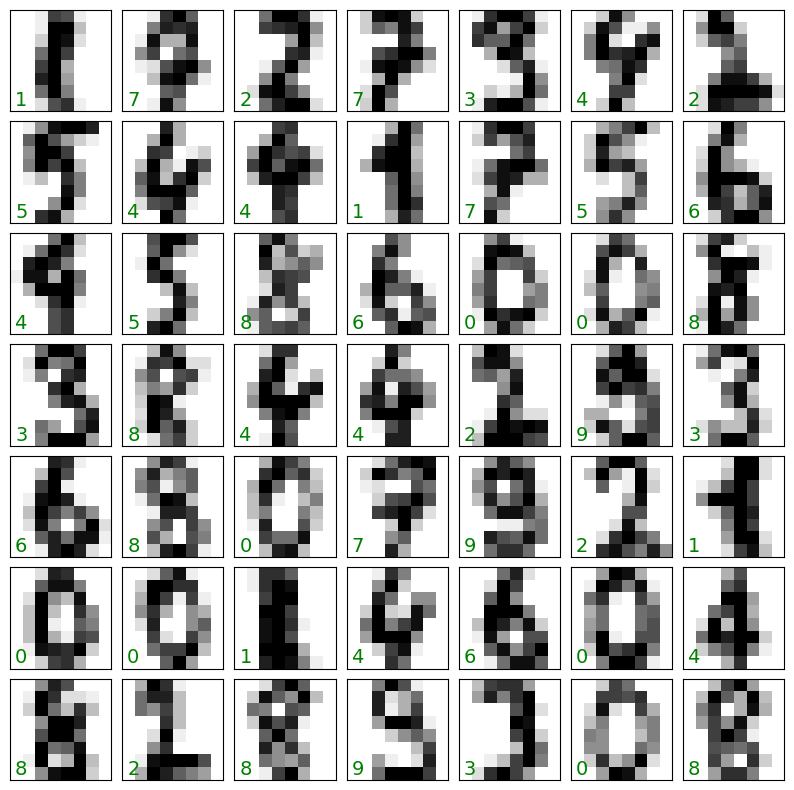

In [14]:
fig, axes = plt.subplots(7,7, figsize=(10, 10))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

np.random.seed(42)
mychoices = np.random.choice(digits.images.shape[0],100)

for i, ax in enumerate(axes.flat):
    ax.imshow((digits.images[mychoices[i]]), 
              cmap='binary')
    ax.text(0.05, 0.05, str(digits.target[mychoices[i]]),transform=ax.transAxes, color='green', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])
 

In [ ]:
#not all pixels are necessary (ex. some are always blank) -> we want to reduce the space

In [133]:
embedding = Isomap(n_components=5)

In [134]:
X, y = datasets.load_digits(return_X_y=True)
X_transformed = embedding.fit_transform(X)
X_transformed.shape

/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/scipy/sparse/_index.py:100: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])


(1797, 5)

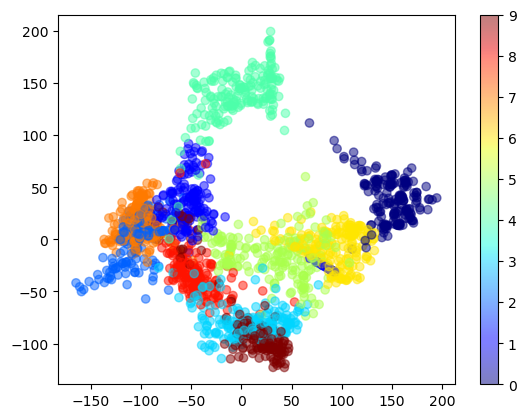

In [135]:
plt.scatter(X_transformed[:,0],X_transformed[:,1],c=digits.target,alpha=0.5,cmap='jet')
plt.colorbar()

In [136]:
digits.target

array([0, 1, 2, ..., 8, 9, 8])

In [137]:
Xtrain, Xtest, ytrain, ytest = sklearn.model_selection.train_test_split(X_transformed, y,test_size=0.2)

In [143]:
logistic = LogisticRegression(max_iter=10000, solver='sag')
log = logistic.fit(X_transformed, digits.target)

In [144]:
acc = log.score(X_transformed, digits.target)
acc

0.9749582637729549

In [145]:
acc = sklearn.metrics.accuracy_score( digits.target, log.predict(X_transformed))
acc

0.9749582637729549

In [146]:
print(confusion_matrix(digits.target, log.predict(X_transformed)))

[[178   0   0   0   0   0   0   0   0   0]
 [  0 181   1   0   0   0   0   0   0   0]
 [  0   0 173   0   0   0   0   0   4   0]
 [  0   0   0 173   0   1   0   2   5   2]
 [  0   0   0   0 180   0   0   0   0   1]
 [  0   1   0   0   0 178   1   0   0   2]
 [  0   6   0   0   0   1 174   0   0   0]
 [  0   0   0   0   0   0   0 178   0   1]
 [  0   4   3   3   0   0   0   0 162   2]
 [  0   0   0   2   0   2   0   0   1 175]]
